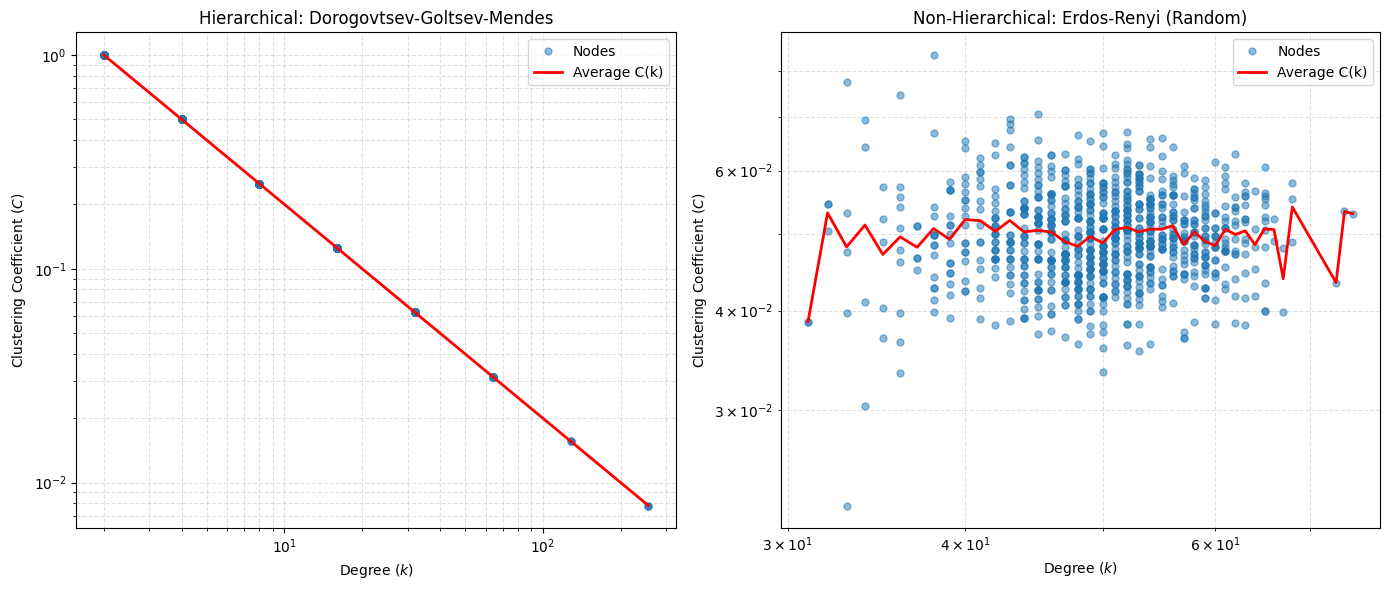

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_clustering_vs_degree(G, title="C(k) Relation"):
    degree_dict = dict(G.degree())
    clustering_dict = nx.clustering(G)
    
    k_values = []
    c_values = []
    
    for node in G.nodes():
        k = degree_dict[node]
        c = clustering_dict[node]
        if k > 0 and c > 0:
            k_values.append(k)
            c_values.append(c)

    plt.loglog(k_values, c_values, 'o', alpha=0.5, markersize=5, label='Nodes')
    
    if len(k_values) > 0:
        k_unique = sorted(list(set(k_values)))
        c_mean = []
        for k in k_unique:
            vals = [c for i, c in enumerate(c_values) if k_values[i] == k]
            c_mean.append(np.mean(vals))
        plt.loglog(k_unique, c_mean, 'r-', linewidth=2, label='Average C(k)')

    plt.title(title)
    plt.xlabel(r'Degree ($k$)')
    plt.ylabel(r'Clustering Coefficient ($C$)')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.4)


G_hierarchical = nx.dorogovtsev_goltsev_mendes_graph(n=8) 
G_non_hierarchical = nx.erdos_renyi_graph(n=1000, p=0.05)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_clustering_vs_degree(G_hierarchical, "Hierarchical: Dorogovtsev-Goltsev-Mendes")

plt.subplot(1, 2, 2)
plot_clustering_vs_degree(G_non_hierarchical, "Non-Hierarchical: Erdos-Renyi")

plt.tight_layout()
plt.show()



In [6]:
import pandas as pd
import os 

def load_gtfs_file(filename, use_cols=None, drop_cols=None):
    filepath = os.path.join("gtfs", filename)
    df = pd.read_csv(filepath, usecols=use_cols)
    if drop_cols:
        df = df.drop(columns=drop_cols, errors='ignore')
    return df

def clean_and_process_gtfs_data():
    df_cal = load_gtfs_file("calendar.txt", use_cols=["service_id", "start_date", "end_date"])
    df_trips = load_gtfs_file("trips.txt", drop_cols=["trip_headsign", "direction_id", "shape_id"])
    df_routes = load_gtfs_file("routes.txt", drop_cols=["agency_id", "route_long_name", "route_desc"])
    df_stop_times = load_gtfs_file("stop_times.txt", drop_cols=["stop_headsign", "pickup_type", "drop_off_type", "timepoint"])
    df_stops = load_gtfs_file("stops.txt", drop_cols=["stop_code"])

    df = (
        df_cal
        .merge(df_trips, on="service_id")
        .merge(df_routes, on="route_id")
        .merge(df_stop_times, on="trip_id")
        .merge(df_stops, on="stop_id")
    )

    # Remove times >= '24:00:00' to avoid ValueError
    df = df[df["arrival_time"] < '24:00:00']
    df = df[df["departure_time"] < '24:00:00']

    df["start_date"] = pd.to_datetime(df["start_date"], format="%Y%m%d")
    df["end_date"] = pd.to_datetime(df["end_date"], format="%Y%m%d")
    df["arrival_time"] = pd.to_datetime(df["arrival_time"], format="%H:%M:%S").dt.time
    df["departure_time"] = pd.to_datetime(df["departure_time"], format="%H:%M:%S").dt.time

    # Combine date and time to create full datetime objects
    df['arrival_datetime'] = pd.to_datetime(df['start_date'].dt.date.astype(str) + ' ' + df['arrival_time'].astype(str))
    df['departure_datetime'] = pd.to_datetime(df['start_date'].dt.date.astype(str) + ' ' + df['departure_time'].astype(str))

    df.drop(columns=[
        "arrival_time", "departure_time", "start_date", "end_date", "service_id",
        "stop_sequence", "shape_dist_traveled"
    ], inplace=True)

    # Calculate 'next_stop'
    df = df.sort_values(by=['trip_id', 'arrival_datetime'])
    df["next_stop"] = df.groupby("trip_id")["stop_id"].shift(-1).fillna(-1).astype('int')

    return df

df = clean_and_process_gtfs_data()
df.head(-10)

,route_id,trip_id,route_short_name,route_type,stop_id,stop_name,stop_lat,stop_lon,arrival_datetime,departure_datetime,next_stop
301157,0_104,0_2_1963149,104,3,7053,Metro Bródno,52.293529,21.031043,2025-12-09 06:15:00,2025-12-09 06:15:00,1614
301158,0_104,0_2_1963149,104,3,1614,Metro Bródno,52.293676,21.032621,2025-12-09 06:17:00,2025-12-09 06:17:00,1751
301159,0_104,0_2_1963149,104,3,1751,Suwalska,52.296123,21.032985,2025-12-09 06:18:00,2025-12-09 06:18:00,1750
301160,0_104,0_2_1963149,104,3,1750,Turmoncka,52.298815,21.032966,2025-12-09 06:19:00,2025-12-09 06:19:00,1627
301161,0_104,0_2_1963149,104,3,1627,Kopijników,52.300338,21.031980,2025-12-09 06:20:00,2025-12-09 06:20:00,1628
...,...,...,...,...,...,...,...,...,...,...,...
5846559,6_518,6_2_4827673,518,3,4058,Odkryta,52.324678,20.937698,2025-12-16 22:25:00,2025-12-16 22:25:00,4056
5846560,6_518,6_2_4827673,518,3,4056,Nowodworska,52.320643,20.940360,2025-12-16 22:26:00,2025-12-16 22:26:00,4870
5846561,6_518,6_2_4827673,518,3,4870,Pancera,52.318314,20.946588,2025-12-16 22:27:00,2025-12-16 22:27:00,1677
5846562,6_518,6_2_4827673,518,3,1677,Tarchomin,52.316341,20.952537,2025-12-16 22:28:00,2025-12-16 22:28:00,1676


# Keep in mind that I am not graphing for buses since there are thousands of bus stops that would need to be mapped right now

Built Tram network: 619 stops, 757 connections.
Built Rail network: 62 stops, 126 connections.
Built Bus network: 6031 stops, 7844 connections.


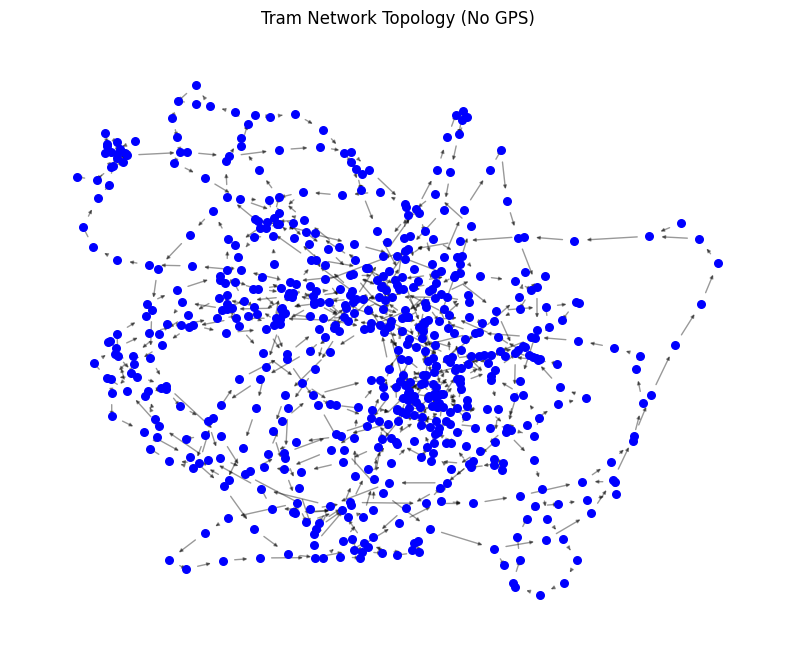

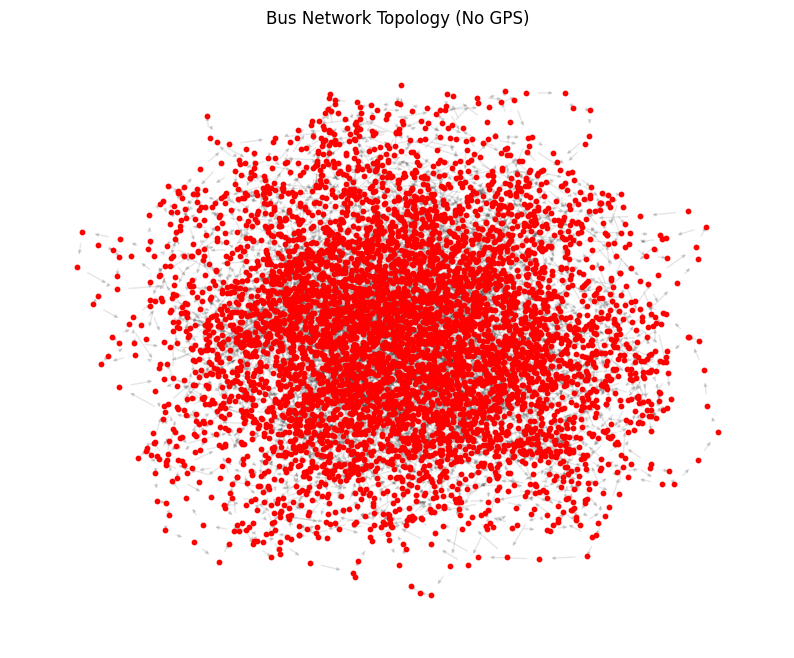

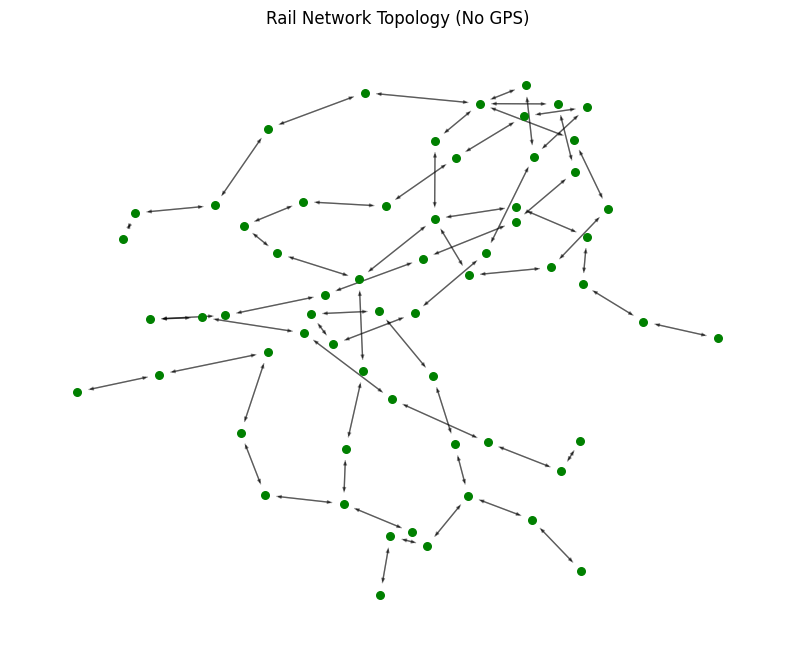

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

def build_transport_graphs(df):
    """
    Splits the main dataframe by route_type and builds a directed graph 
    for each transport mode.
    """
    mode_map = {0: 'Tram', 2: 'Rail', 3: 'Bus'} #add bus to graph but takes much time
    graphs = {}
    valid_connections = df[df['next_stop'] != -1].copy()

    for r_type, mode_name in mode_map.items():
        subset = valid_connections[valid_connections['route_type'] == r_type]
        
        if subset.empty:
            print(f"No data found for {mode_name} (type {r_type})")
            continue
            
        G = nx.DiGraph()
        edges = subset[['stop_id', 'next_stop']].drop_duplicates().values
        G.add_edges_from(edges)
        
        graphs[mode_name] = G
        print(f"Built {mode_name} network: {G.number_of_nodes()} stops, {G.number_of_edges()} connections.")
        
    return graphs

def plot_transport_networks(graphs):
    """
    Draws the networks side by side or sequentially.
    """
    modes_to_plot = ['Tram', 'Bus', 'Rail']
    
    for mode in modes_to_plot:
        if mode not in graphs:
            continue
            
        G = graphs[mode]
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, k=0.15, iterations=20) 
        
        node_size = 10 if mode == 'Bus' else 30
        edge_alpha = 0.1 if mode == 'Bus' else 0.4
        color = 'red' if mode == 'Bus' else ('blue' if mode == 'Tram' else 'green')
        
        nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=color)
        nx.draw_networkx_edges(G, pos, alpha=edge_alpha, arrows=True, arrowsize=5)
        
        plt.title(f"{mode} Network Topology (No GPS)")
        plt.axis('off')
        plt.show()

transport_graphs = build_transport_graphs(df)
plot_transport_networks(transport_graphs)

In [31]:
def get_network_metrics(G, name):
    """
    Calculates basic metrics for a single graph G.
    """
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    
    degrees = [d for n, d in G.degree()]
    avg_degree = np.mean(degrees) if degrees else 0
    
    density = nx.density(G)

    avg_clustering = nx.average_clustering(G)
    
    if G.is_directed():
        num_components = nx.number_weakly_connected_components(G)
        largest_cc_nodes = max(nx.weakly_connected_components(G), key=len)
        largest_subgraph = G.subgraph(largest_cc_nodes).copy()
    else:
        num_components = nx.number_connected_components(G)
        largest_cc_nodes = max(nx.connected_components(G), key=len)
        largest_subgraph = G.subgraph(largest_cc_nodes).copy()
        
    try:

        if largest_subgraph.number_of_nodes() > 5000:
            avg_path_len = np.nan 
            diameter = np.nan
        else:
            avg_path_len = nx.average_shortest_path_length(largest_subgraph)
            diameter = nx.diameter(largest_subgraph)
    except Exception as e:
        avg_path_len = np.nan
        diameter = np.nan

    return {
        "Layer": name,
        "Nodes": num_nodes,
        "Edges": num_edges,
        "Avg Degree": round(avg_degree, 4),
        "Density": round(density, 6),
        "Avg Clustering": round(avg_clustering, 4),
        "Components": num_components,
        "Avg Path Len (LCC)": round(avg_path_len, 4) if not np.isnan(avg_path_len) else "Too Large",
        "Diameter (LCC)": diameter if not np.isnan(diameter) else "Too Large"
    }

def analyze_all_layers(graphs_dict):
    """
    Analyzes each individual layer and the combined whole network.
    """
    results = []
    
    for name, G in graphs_dict.items():
        print(f"Analyzing {name} layer")
        metrics = get_network_metrics(G, name)
        results.append(metrics)
        
    print("Combining layers for Whole Network analysis")
    all_graphs = list(graphs_dict.values())
    if all_graphs:
        whole_network = nx.compose_all(all_graphs)
        metrics = get_network_metrics(whole_network, "Whole Network")
        results.append(metrics)
    
    df_results = pd.DataFrame(results)
    return df_results, whole_network


metrics_df, whole_G = analyze_all_layers(transport_graphs)
metrics_df.head()

Analyzing Tram layer
Analyzing Rail layer
Analyzing Bus layer
Combining layers for Whole Network analysis


,Layer,Nodes,Edges,Avg Degree,Density,Avg Clustering,Components,Avg Path Len (LCC),Diameter (LCC)
0,Tram,619,757,2.4459,0.001979,0.0010,1,Too Large,Too Large
1,Rail,62,126,4.0645,0.033316,0.0000,1,9.6605,26
2,Bus,6031,7844,2.6012,0.000216,0.0112,1,Too Large,Too Large
3,Whole Network,6696,8721,2.6048,0.000195,0.0102,2,Too Large,Too Large


In [20]:
import networkx as nx
import matplotlib.pyplot as plt

def get_stop_coordinates(df):
    """
    Extracts a dictionary of coordinates {stop_id: (lon, lat)} from the dataframe.
    """

    coords_df = df[['stop_id', 'stop_lon', 'stop_lat']].drop_duplicates()
    
    pos = {
        row['stop_id']: (row['stop_lon'], row['stop_lat']) 
        for _, row in coords_df.iterrows()
    }
    return pos

def plot_geographic_networks(graphs, pos):
    """
    Draws the graphs using the provided GPS coordinates.
    """
    for mode, G in graphs.items():
        plt.figure(figsize=(12, 10))
        

        current_pos = {node: pos[node] for node in G.nodes() if node in pos}
        
        if not current_pos:
            print(f"No coordinates found for {mode} network.")
            continue

        node_size = 5 if mode == 'Bus' else 20
        edge_alpha = 0.05 if mode == 'Bus' else 0.5
        edge_width = 0.5 if mode == 'Bus' else 1.5
        color = 'red' if mode == 'Bus' else ('blue' if mode == 'Tram' else 'green')
        
        nx.draw_networkx_nodes(G, current_pos, node_size=node_size, node_color=color, label=mode)
        nx.draw_networkx_edges(G, current_pos, alpha=edge_alpha, width=edge_width, arrows=False)
        
        plt.title(f"{mode} Network - Geographic Configuration")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        
        plt.axis('equal') 
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.show()

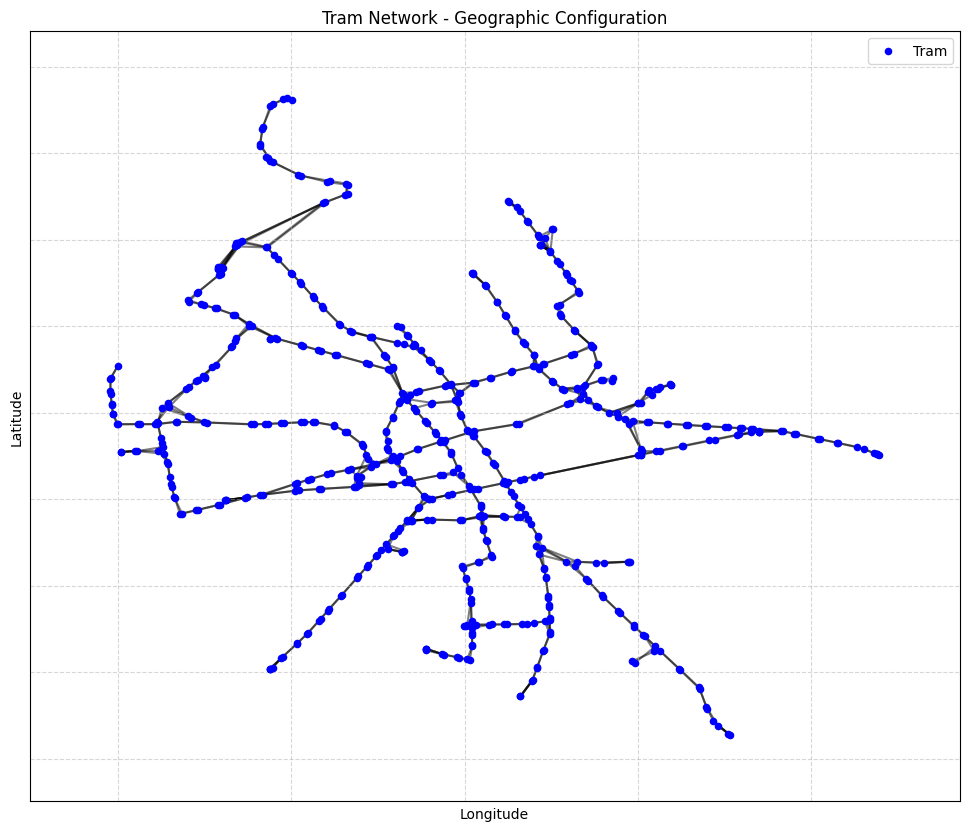

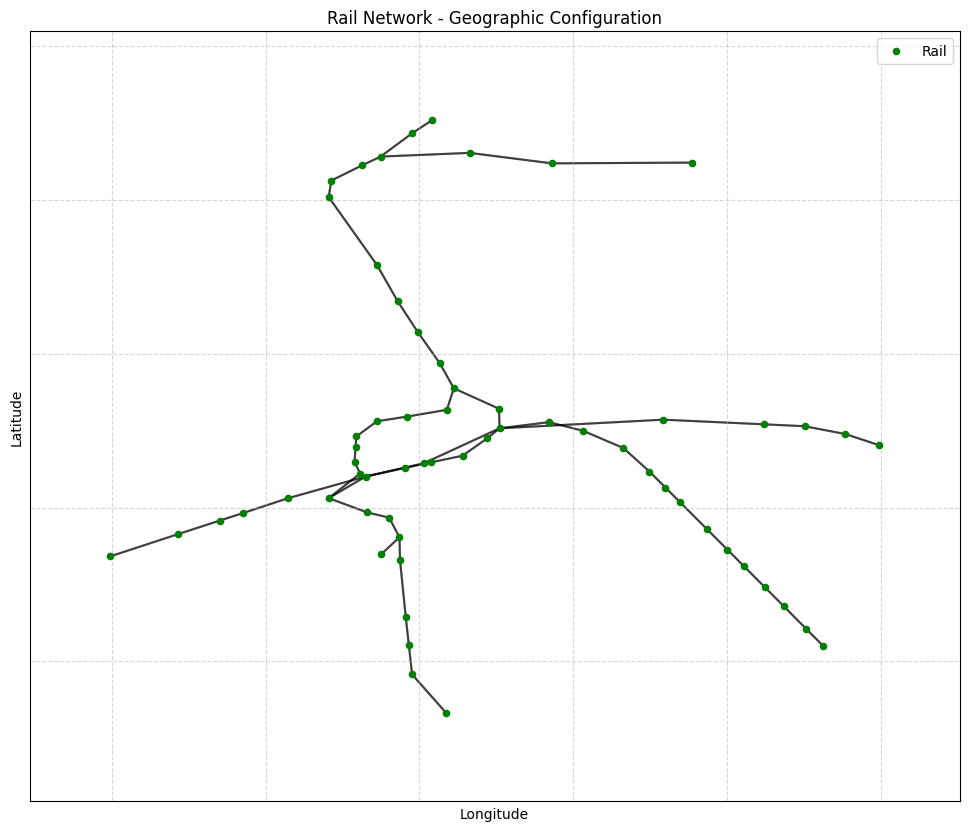

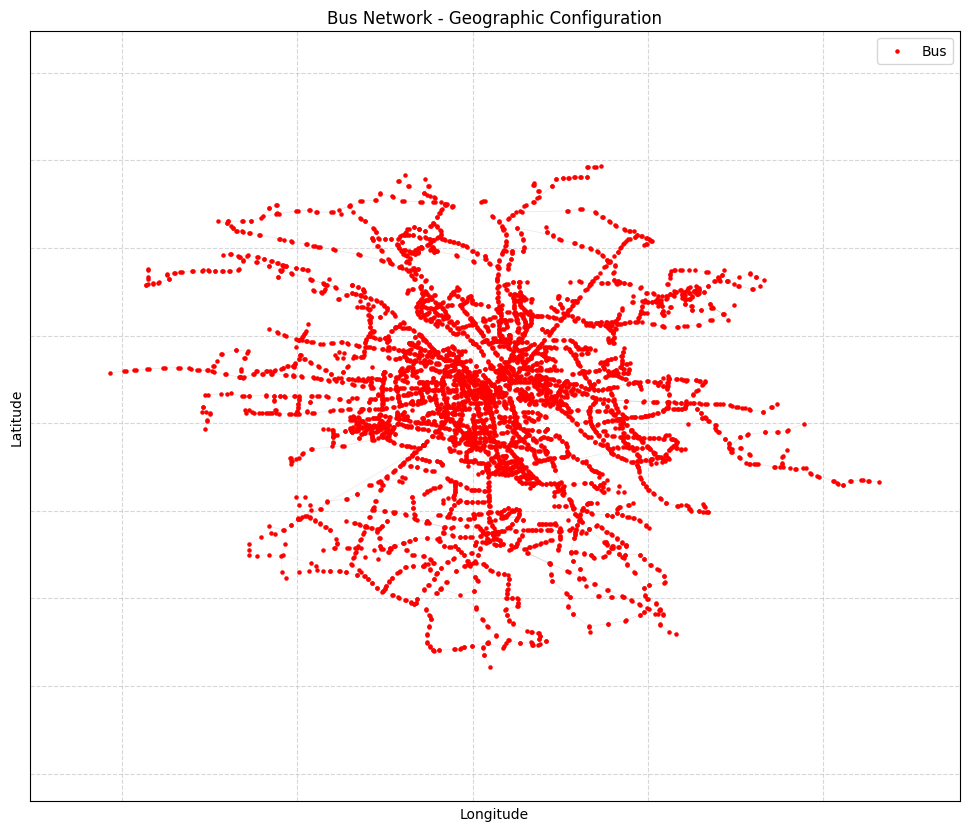

In [21]:
stop_pos = get_stop_coordinates(df)
plot_geographic_networks(transport_graphs, stop_pos)

In [27]:
import pandas as pd

def create_temporal_network(df):
    """
    Transforms the schedule dataframe into a temporal edge list.
    Returns a DataFrame where each row is a temporal edge active from t_start to t_end.
    """
    temp_df = df.copy()
    
    temp_df = temp_df.sort_values(by=['trip_id', 'arrival_datetime'])
    
    temp_df['next_arrival_datetime'] = temp_df.groupby('trip_id')['arrival_datetime'].shift(-1)
    
    mask = (temp_df['next_stop'] != -1) & (temp_df['next_arrival_datetime'].notna())
    temporal_edges = temp_df[mask].copy()

    temporal_edges = temporal_edges[[
        'stop_id',
        'next_stop',
        'departure_datetime',
        'next_arrival_datetime',
        'route_type'
    ]]
    
    temporal_edges.columns = ['u', 'v', 't_start', 't_end', 'mode']
    temporal_edges = temporal_edges.sort_values(by='t_start')
    
    return temporal_edges

temporal_network = create_temporal_network(df)

print(f"Total temporal edges (individual trips between stops): {len(temporal_network)}")
print("First 5 temporal events:")
print(temporal_network.head())

Total temporal edges (individual trips between stops): 5562204
First 5 temporal events:
           u     v             t_start               t_end  mode
922075  1536  1537 2025-12-09 03:18:00 2025-12-09 03:19:00     3
900199  1961  1962 2025-12-09 03:18:00 2025-12-09 03:19:00     3
922076  1537  1874 2025-12-09 03:19:00 2025-12-09 03:20:00     3
900200  1962  1996 2025-12-09 03:19:00 2025-12-09 03:21:00     3
922077  1874  1875 2025-12-09 03:20:00 2025-12-09 03:21:00     3


MovieWriter ffmpeg unavailable; using Pillow instead.


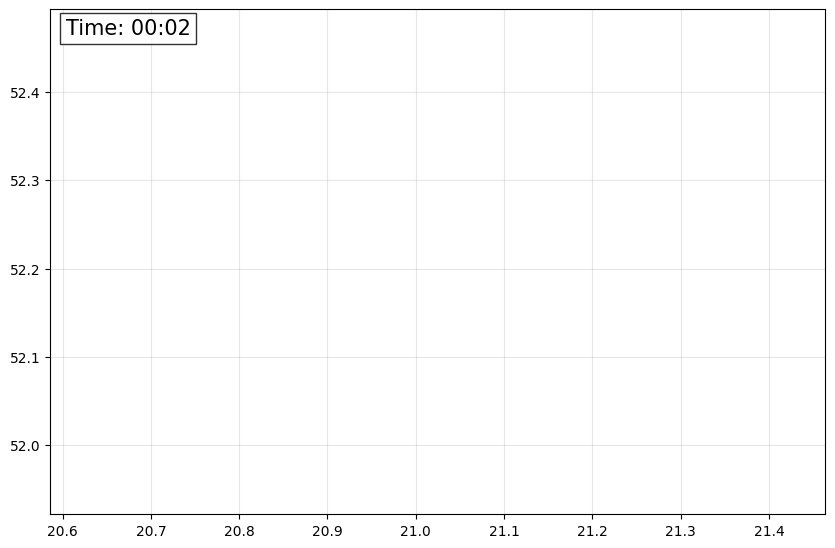

In [29]:
import matplotlib.animation as animation
from datetime import timedelta

def animate_traffic(temporal_df, stop_pos, output_file="traffic_flow.mp4"):
    """
    Creates an animation of traffic flow.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    lons = [p[0] for p in stop_pos.values()]
    lats = [p[1] for p in stop_pos.values()]
    ax.set_xlim(min(lons), max(lons))
    ax.set_ylim(min(lats), max(lats))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    scatter = ax.scatter([], [], c=[], s=15, alpha=0.8)
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=15, 
                        bbox=dict(facecolor='white', alpha=0.8))
    
    start_time_str = "04:00:00"
    end_time_str = "23:59:00"
    step_minutes = 2
    
    base_date = temporal_df['t_start'].iloc[0].date()
    current_time = pd.Timestamp(f"{base_date} {start_time_str}")
    end_time = pd.Timestamp(f"{base_date} {end_time_str}")
    
    def update(frame):
        nonlocal current_time
        

        active_mask = (temporal_df['t_start'] <= current_time) & (temporal_df['t_end'] > current_time)
        active_trips = temporal_df[active_mask]
        
        positions = []
        colors = []
        
        for _, row in active_trips.iterrows():
            u, v = row['u'], row['v']
            if u in stop_pos and v in stop_pos:
                p1 = np.array(stop_pos[u])
                p2 = np.array(stop_pos[v])
                
                total = (row['t_end'] - row['t_start']).total_seconds()
                curr = (current_time - row['t_start']).total_seconds()
                alpha = curr / total if total > 0 else 1.0
                
                pos = p1 + alpha * (p2 - p1)
                positions.append(pos)
                
                c = 'red' if row['mode'] == 3 else ('blue' if row['mode'] == 0 else 'green')
                colors.append(c)
        
        if positions:
            scatter.set_offsets(positions)
            scatter.set_color(colors)
        else:
            scatter.set_offsets(np.empty((0, 2)))
            
        time_text.set_text(f"Time: {current_time.strftime('%H:%M')}")
        
        current_time += timedelta(minutes=step_minutes)
        return scatter, time_text

    total_minutes = (end_time - pd.Timestamp(f"{base_date} {start_time_str}")).total_seconds() / 60
    frames = int(total_minutes / step_minutes)
    
    ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
    
    ani.save(output_file, writer='ffmpeg', fps=30)
    plt.show()

animate_traffic(temporal_network, stop_pos, output_file="traffic_flow_to_24.gif")

Calculating hourly metrics


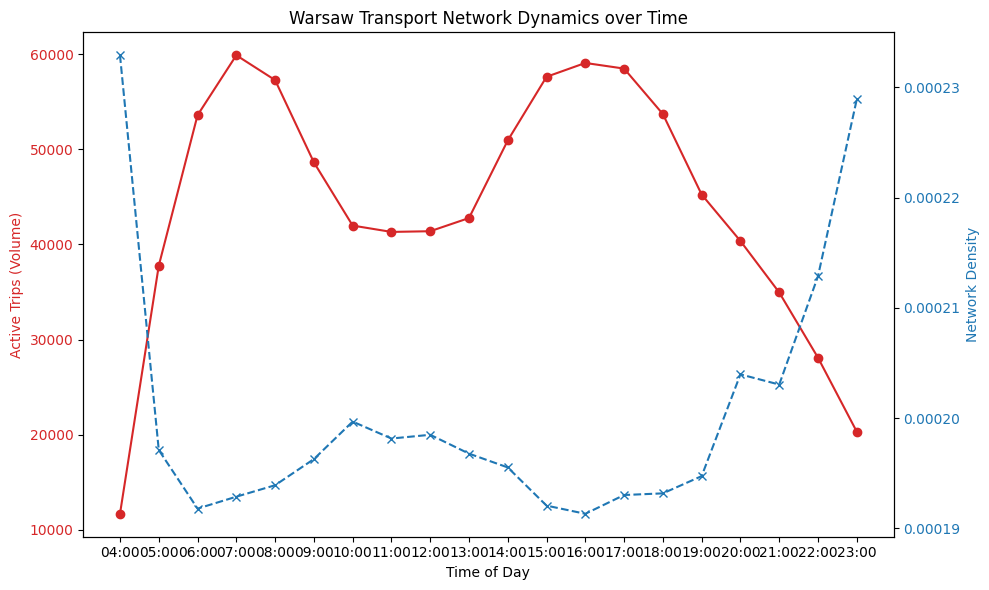

In [30]:
def analyze_temporal_metrics(temporal_df, stop_pos):
    """
    Calculates network metrics for hourly windows throughout the day.
    """
    results = []
    
    start_hour = 4
    end_hour = 24
    
    base_date = temporal_df['t_start'].iloc[0].date()
    
    print("Calculating hourly metrics")
    
    for h in range(start_hour, end_hour):
        t_window_start = pd.Timestamp(f"{base_date} {h:02d}:00:00")
        t_window_end = t_window_start + timedelta(hours=1)
        
        mask = (
            (temporal_df['t_start'] < t_window_end) & 
            (temporal_df['t_end'] > t_window_start)
        )
        hourly_edges = temporal_df[mask]
        
        if hourly_edges.empty:
            continue
            
        G = nx.DiGraph()
        G.add_edges_from(hourly_edges[['u', 'v']].values)
        
        n = G.number_of_nodes()
        e = G.number_of_edges()
        density = nx.density(G)

        active_trips = len(hourly_edges)
        
        results.append({
            "Hour": f"{h:02d}:00",
            "Active Stops": n,
            "Connections": e,
            "Active Trips": active_trips,
            "Density": density
        })
        
    df_metrics = pd.DataFrame(results)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    ax1.set_xlabel('Time of Day')
    ax1.set_ylabel('Active Trips (Volume)', color='tab:red')
    ax1.plot(df_metrics['Hour'], df_metrics['Active Trips'], color='tab:red', marker='o', label='Trips')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    
    ax2 = ax1.twinx() 
    ax2.set_ylabel('Network Density', color='tab:blue')
    ax2.plot(df_metrics['Hour'], df_metrics['Density'], color='tab:blue', linestyle='--', marker='x', label='Density')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    
    plt.title("Warsaw Transport Network Dynamics over Time")
    fig.tight_layout()
    plt.show()
    
    return df_metrics

metrics_over_time = analyze_temporal_metrics(temporal_network, stop_pos)

In [ ]:
import pandas as pd
import numpy as np

def get_traffic_at_timestamp(temporal_df, stop_pos, target_time_str):
    """
    Calculates the position of all vehicles at a specific timestamp.
    Returns:
        positions (np.array): Array of [x, y] coordinates.
        colors (list): List of colors corresponding to each vehicle.
    """
    base_date = temporal_df['t_start'].iloc[0].date()
    target_time = pd.Timestamp(f"{base_date} {target_time_str}")
    
    active_mask = (temporal_df['t_start'] <= target_time) & (temporal_df['t_end'] > target_time)
    active_trips = temporal_df[active_mask].copy()
    
    current_positions = []
    colors = []
    
    for _, row in active_trips.iterrows():
        u, v = row['u'], row['v']
        
        if u not in stop_pos or v not in stop_pos:
            continue
            
        start_coords = np.array(stop_pos[u])
        end_coords = np.array(stop_pos[v])
        
        total_duration = (row['t_end'] - row['t_start']).total_seconds()
        elapsed = (target_time - row['t_start']).total_seconds()
        
        if total_duration > 0:
            alpha = elapsed / total_duration
        else:
            alpha = 1.0
            
        current_pos = start_coords + alpha * (end_coords - start_coords)
        current_positions.append(current_pos)
        
        if row['mode'] == 3: colors.append('red')    
        elif row['mode'] == 0: colors.append('blue') 
        elif row['mode'] == 1: colors.append('green')
        else: colors.append('black')
        
    return np.array(current_positions), colors

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import contextily as ctx
import pandas as pd
import numpy as np
from datetime import timedelta

def animate_traffic_with_map(temporal_df, stop_pos, output_file="traffic_map.gif"):
    """
    Creates an animation of traffic flow over a real map of Warsaw.
    """
    fig, ax = plt.subplots(figsize=(12, 12))
    
    lons = [p[0] for p in stop_pos.values()]
    lats = [p[1] for p in stop_pos.values()]
    
    buffer = 0.02
    min_lon, max_lon = min(lons) - buffer, max(lons) + buffer
    min_lat, max_lat = min(lats) - buffer, max(lats) + buffer
    
    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)
    ax.set_axis_off()
    
    try:
        ctx.add_basemap(ax, 
                        crs='EPSG:4326',
                        source=ctx.providers.OpenStreetMap.Mapnik,
                        alpha=0.8)
    except Exception as e:
        print(f"Map Error: {e}")

    scatter = ax.scatter([], [], c=[], s=20, alpha=0.9, zorder=3)
    
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=15, 
                        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

    start_time_str = "06:00:00"
    end_time_str = "10:00:00"
    step_minutes = 2
    
    base_date = temporal_df['t_start'].iloc[0].date()
    current_time = pd.Timestamp(f"{base_date} {start_time_str}")
    end_time = pd.Timestamp(f"{base_date} {end_time_str}")
    
    def update(frame):
        nonlocal current_time
        
        active_mask = (temporal_df['t_start'] <= current_time) & (temporal_df['t_end'] > current_time)
        active_trips = temporal_df[active_mask]
        
        positions = []
        colors = []
        
        for _, row in active_trips.iterrows():
            u, v = row['u'], row['v']
            if u in stop_pos and v in stop_pos:
                p1 = np.array(stop_pos[u])
                p2 = np.array(stop_pos[v])
                
                total = (row['t_end'] - row['t_start']).total_seconds()
                curr = (current_time - row['t_start']).total_seconds()
                alpha = curr / total if total > 0 else 1.0
                
                pos = p1 + alpha * (p2 - p1)
                positions.append(pos)
                
                c = 'red' if row['mode'] == 3 else ('blue' if row['mode'] == 0 else 'green')
                colors.append(c)
        
        if positions:
            scatter.set_offsets(positions)
            scatter.set_color(colors)
        else:
            scatter.set_offsets(np.empty((0, 2)))
            
        time_text.set_text(f"Time: {current_time.strftime('%H:%M')}")
        
        current_time += timedelta(minutes=step_minutes)
        return scatter, time_text

    total_minutes = (end_time - pd.Timestamp(f"{base_date} {start_time_str}")).total_seconds() / 60
    frames = int(total_minutes / step_minutes)
    
    ani = animation.FuncAnimation(fig, update, frames=frames, interval=100, blit=True)
    
    if output_file.endswith('.mp4'):
        ani.save(output_file, writer='ffmpeg', fps=60)
    else:
        ani.save(output_file, writer='pillow', fps=60)
        
    print(f"Animation saved to {output_file}")
    plt.close()

animate_traffic_with_map(temporal_network, stop_pos, "warsaw_traffic.gif")

Generating animation frames...
Animation saved to warsaw_traffic.gif
